<a href="https://colab.research.google.com/github/pyafv/assets/blob/main/jupyter/standard_voronoi_sim.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Standard Voronoi Model via `pyafv`

This notebook simulates the **standard Voronoi model** of epithelial tissue using the `pyafv` package.

**Note:** `pyafv` is designed for the *finite* Voronoi model; adapting it here incurs some extra overhead from identifying outer vertices, but the underlying physics is identical to the standard Voronoi model.

In [ ]:
!pip install pyafv

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from pyafv import FiniteVoronoiSimulator, PhysicalParams
from tqdm.notebook import tqdm

In [3]:
np.random.seed(42)    # fix random seed for reproducibility

### Model parameters

In [4]:
N = 100
# Large radius → outer (finite-Voronoi) vertices are rarely activated, recovering standard Voronoi behavior
radius = 10.0
params = PhysicalParams(P0=6.9, r=radius)

# Shape index p0 = P0 / sqrt(A0) controls the solid-fluid rigidity transition
# p0 < ~3.81 → jammed (solid-like);  p0 > ~3.81 → unjammed (fluid-like)
print(f"Target shape index: {params.P0 / np.sqrt(params.A0)}")

Target shape index: 3.892908126479519


In [5]:
# Box length L chosen so that the mean cell area equals A0 (confluent tissue: no gaps, no overlaps)
L = np.sqrt(N * params.A0)
pts = np.random.rand(N, 2) * L    # shape (N, 2)

### Initial configuration

<Axes: >

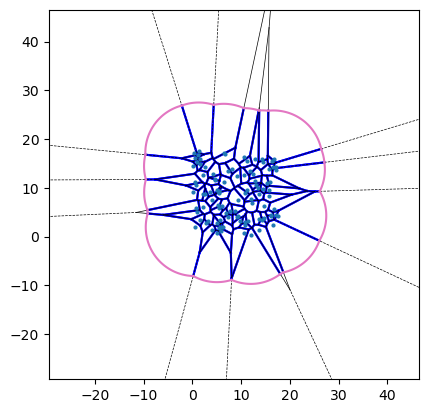

In [6]:
sim = FiniteVoronoiSimulator(pts, params)
sim.plot_2d()

### Periodic Boundary Conditions

The function below is exactly the PBC tiling function we have used in [**#4 Periodic boundary conditions**](periodic_plotting.ipynb).

In [7]:
def tile_pbc_with_index(pts: np.ndarray, r: float, L: float):
    """
    Periodic tiling of pts (N,2), with bookkeeping.
    Returns:
        pos_pbc  : (M,2) tiled positions
        idx_orig : (M,) indices mapping each tiled point back to original 0..N-1
    """
    pts = np.asarray(pts)
    N = pts.shape[0]
    thresh = 2.01 * r

    x = pts[:, 0]
    y = pts[:, 1]

    # --- Stage 1: originals + left/right ---
    mask_l = x <= thresh
    mask_r = x >= (L - thresh)
    inds_l = np.flatnonzero(mask_l)
    inds_r = np.flatnonzero(mask_r)
    n_l, n_r = inds_l.size, inds_r.size

    NA = N + n_l + n_r
    pos_aug = np.empty((NA, 2), dtype=pts.dtype)
    idx_aug = np.empty(NA, dtype=np.int64)

    # originals
    pos_aug[:N] = pts
    idx_aug[:N] = np.arange(N, dtype=np.int64)
    i = N

    # left (+L, 0)
    if n_l:
        sl = slice(i, i+n_l)
        pos_aug[sl] = pts[inds_l]
        pos_aug[sl, 0] += L
        idx_aug[sl] = inds_l
        i += n_l

    # right (−L, 0)
    if n_r:
        sl = slice(i, i+n_r)
        pos_aug[sl] = pts[inds_r]
        pos_aug[sl, 0] -= L
        idx_aug[sl] = inds_r
        i += n_r

    # --- Stage 2: on augmented, append down then up ---
    y_aug = pos_aug[:, 1]
    inds_d = np.flatnonzero(y_aug <= thresh)
    inds_u = np.flatnonzero(y_aug >= (L - thresh))
    n_d, n_u = inds_d.size, inds_u.size

    M = NA + n_d + n_u
    pos_out = np.empty((M, 2), dtype=pts.dtype)
    idx_out = np.empty(M, dtype=np.int64)

    pos_out[:NA] = pos_aug
    idx_out[:NA] = idx_aug
    j = NA

    # down (0, +L)
    if n_d:
        sl = slice(j, j+n_d)
        pos_out[sl] = pos_aug[inds_d]
        pos_out[sl, 1] += L
        idx_out[sl] = idx_aug[inds_d]
        j += n_d

    # up (0, −L)
    if n_u:
        sl = slice(j, j+n_u)
        pos_out[sl] = pos_aug[inds_u]
        pos_out[sl, 1] -= L
        idx_out[sl] = idx_aug[inds_u]

    return pos_out, idx_out

In [8]:
# Tile the box with ghost cells near boundaries, then pass the full set to the simulator
pts_pbc, idx_pbc = tile_pbc_with_index(pts, radius, L)
sim.update_positions(pts_pbc)

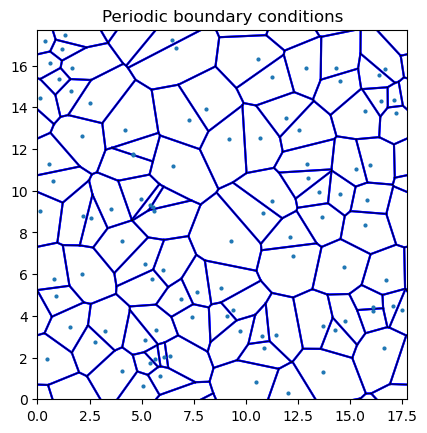

In [9]:
fig, ax = plt.subplots(dpi=100)
ax = sim.plot_2d()

ax.set_xlim(0, L)
ax.set_ylim(0, L)
ax.set_title("Periodic boundary conditions")

plt.show()

### Relaxation

In [10]:
dt = 0.01   # step size
for _ in tqdm(range(1000)):
    diag = sim.build()
    pts += diag["forces"][:N] * dt                          # update only the N real cells (ghost forces are discarded)
    pts = pts % L                                           # wrap positions back into [0, L)² (periodic boundary)
    pts_pbc, idx_pbc = tile_pbc_with_index(pts, radius, L)  # re-tile with updated positions
    sim.update_positions(pts_pbc)                           # push tiled positions to the simulator for next build()

  0%|          | 0/1000 [00:00<?, ?it/s]

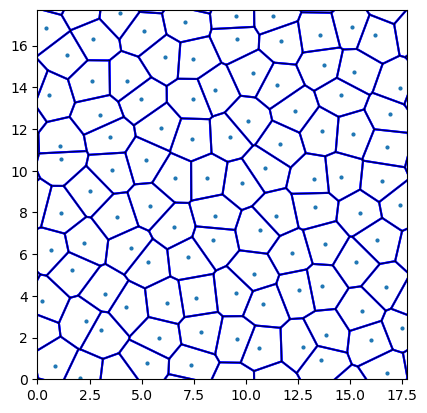

In [11]:
fig, ax = plt.subplots(dpi=100)
ax = sim.plot_2d()
ax.set_xlim(0, L)
ax.set_ylim(0, L)
plt.show()

### Custom visualization

In [12]:
def custom_plot_2d(pts: np.ndarray, cell_colors: np.ndarray, diag: dict, r: float, ax=None):
    """
    Custom plot function
    """
    if ax is None:
        ax = plt.gca()
    
    point_vertices_f_idx = diag["regions"]
    vertices_all = diag["vertices"]

    # Draw cell centers
    ax.plot(pts[:, 0], pts[:, 1], 'o', color='lightgray', markersize=2, zorder=3, clip_on=True)

    N = len(pts)

    # Draw each cell boundary
    for idx in range(N):
        vertices_f_idx = point_vertices_f_idx[idx].copy()

        vertices_f_idx.append(vertices_f_idx[0])
        boundary = vertices_all[vertices_f_idx]

        ax.plot(boundary[:, 0], boundary[:, 1], color="lightgray", lw=1., zorder=2)
        ax.fill(boundary[:, 0], boundary[:, 1], color=cell_colors[idx], lw=0, zorder=0)

    ax.set_aspect("equal")
    return ax

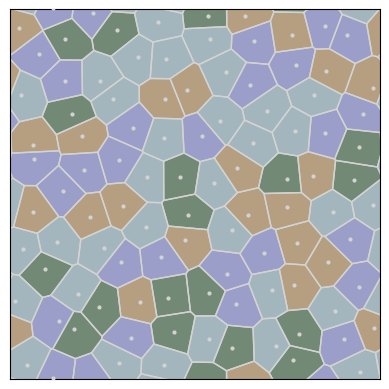

In [13]:
# Four muted colors chosen for a tissue-like appearance
base_colors = ["#9A9EC8", "#B69F80", "#728A75", "#A3B6BD"]
# Assign a random color to each of the N original cells;
cell_colors = np.random.choice(base_colors, size=N)

fig, ax = plt.subplots(dpi=100)
ax = custom_plot_2d(pts_pbc, cell_colors[idx_pbc], diag, r=radius)  # broadcast to ghost copies by indexing with idx_pbc

ax.tick_params(axis='both', length=0, labelbottom=False, labelleft=False)
ax.set_facecolor('#474340')   # dark background
ax.set_xlim(0, L)
ax.set_ylim(0, L)
plt.show()

### Vectorized plotting

In [14]:
from matplotlib.collections import LineCollection, PolyCollection

def custom_plot_2d_fast(pts: np.ndarray, cell_colors: list, diag: dict, r: float, ax=None):
    """
    Faster custom plot function (vectorized version)
    
    The speedup is especially noticeable when plotting large-N systems and generating many frames for videos.
    """
    if ax is None:
      ax = plt.gca()
    
    point_vertices_f_idx = diag["regions"]
    vertices_all = diag["vertices"]
    
    # Cell centers
    ax.plot(pts[:, 0], pts[:, 1], 'o', color='lightgray', markersize=2, zorder=3, clip_on=True)
    
    # Per-cell closed polygons (ragged list; first vertex re-appended to close the stroke)
    polygons = [vertices_all[[*vs, vs[0]]] for vs in point_vertices_f_idx]
    
    # Fills (per-cell colors)
    ax.add_collection(PolyCollection(polygons, facecolors=cell_colors, linewidths=0, zorder=0))
    
    # Outlines (uniform)
    ax.add_collection(LineCollection(polygons, colors="lightgray", linewidths=1.0, zorder=2))
    
    ax.set_aspect("equal")
    return ax

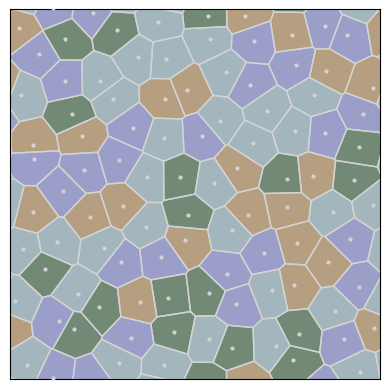

In [15]:
fig, ax = plt.subplots(dpi=100)
ax = custom_plot_2d_fast(pts_pbc, cell_colors[idx_pbc], diag, r=radius)  # broadcast to ghost copies by indexing with idx_pbc

ax.tick_params(axis='both', length=0, labelbottom=False, labelleft=False)
ax.set_facecolor('#474340')   # dark background
ax.set_xlim(0, L)
ax.set_ylim(0, L)
plt.show()